In [26]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from dotenv import load_dotenv, find_dotenv

from doc_chat.evaluation.rag_judge_agent import evaluate_response
from doc_chat.llm import create_llm
from doc_chat.rag.citation_retrieval_chain import CitationRetrievalChain
from doc_chat.rag.document_loader import DocumentLoader
from doc_chat.rag.multi_tenant_vector_store import MultiTenantVectorStore

_ = load_dotenv(find_dotenv())


In [8]:
input_dir = '../../data/single_topic_rag_evaluation_dataset/processed'
documents_file = os.path.join(input_dir, 'documents_processed_2.csv')
pd_documents = pd.read_csv(documents_file)
pd_documents

,index,source_url,text,num_pages,total_word_count,avg_words_per_page,total_char_count,avg_chars_per_page
0,0,https://enterthegungeon.fandom.com/wiki/Bullet...,Bullet Kin\nBullet Kin are one of the most com...,7,1847.0,263.0,10609.0,1515.0
1,1,https://www.dropbox.com/scl/fi/ljtdg6eaucrbf1a...,---The Paths through the Underground/Underdark...,2,470.0,235.0,2737.0,1368.0
2,2,https://bytes-and-nibbles.web.app/bytes/stici-...,Semantic and Textual Inference Chatbot Interfa...,11,3786.0,344.0,22113.0,2010.0
3,3,https://github.com/llmware-ai/llmware,llmware\n\nBuilding Enterprise RAG Pipelines w...,13,3007.0,231.0,20333.0,1564.0
4,4,https://docs.marimo.io/recipes.html,Recipes\nThis page includes code snippets or “...,11,1797.0,163.0,11257.0,1023.0
5,5,https://towardsdatascience.com/how-to-maximize...,How to Maximize Your Impact as a Data Scientis...,8,2446.0,305.0,14217.0,1777.0
6,6,https://ec.europa.eu/commission/presscorner/de...,Why do we need to regulate the use of Artifici...,18,5399.0,299.0,35372.0,1965.0
7,7,https://bg3.wiki/wiki/The_Emperor,The Emperor is a mind flayer who appears in Ba...,10,2973.0,297.0,17889.0,1788.0
8,8,https://whattocook.substack.com/p/so-into-nort...,so into northern spain!\nour magical urban-plu...,6,2046.0,341.0,11259.0,1876.0
9,9,https://dmtalkies.com/the-zone-of-interest-end...,‘The Zone Of Interest’ Ending Explained & Film...,6,2325.0,387.0,13467.0,2244.0


In [3]:
# Load and split the documents
all_splits = []
for index, row in pd_documents.iterrows():
    doc_path = f"{input_dir}/pdf_2/document_{index}.pdf"
    loader = DocumentLoader(doc_path)
    documents, splits = loader.load_and_split()
    pd_documents.loc[index, 'num_splits'] = int(len(splits))
    all_splits.append(splits)

pd_documents['num_splits'] = pd_documents['num_splits'].astype(int)
pd_documents

,index,source_url,text,num_pages,total_word_count,avg_words_per_page,total_char_count,avg_chars_per_page,num_splits
0,0,https://enterthegungeon.fandom.com/wiki/Bullet...,Bullet Kin\nBullet Kin are one of the most com...,7,1847.0,263.0,10609.0,1515.0,14
1,1,https://www.dropbox.com/scl/fi/ljtdg6eaucrbf1a...,---The Paths through the Underground/Underdark...,2,470.0,235.0,2737.0,1368.0,4
2,2,https://bytes-and-nibbles.web.app/bytes/stici-...,Semantic and Textual Inference Chatbot Interfa...,11,3786.0,344.0,22113.0,2010.0,30
3,3,https://github.com/llmware-ai/llmware,llmware\n\nBuilding Enterprise RAG Pipelines w...,13,3007.0,231.0,20333.0,1564.0,27
4,4,https://docs.marimo.io/recipes.html,Recipes\nThis page includes code snippets or “...,11,1797.0,163.0,11257.0,1023.0,17
5,5,https://towardsdatascience.com/how-to-maximize...,How to Maximize Your Impact as a Data Scientis...,8,2446.0,305.0,14217.0,1777.0,18
6,6,https://ec.europa.eu/commission/presscorner/de...,Why do we need to regulate the use of Artifici...,18,5399.0,299.0,35372.0,1965.0,52
7,7,https://bg3.wiki/wiki/The_Emperor,The Emperor is a mind flayer who appears in Ba...,10,2973.0,297.0,17889.0,1788.0,25
8,8,https://whattocook.substack.com/p/so-into-nort...,so into northern spain!\nour magical urban-plu...,6,2046.0,341.0,11259.0,1876.0,17
9,9,https://dmtalkies.com/the-zone-of-interest-end...,‘The Zone Of Interest’ Ending Explained & Film...,6,2325.0,387.0,13467.0,2244.0,16


In [9]:
# create vector store
chroma_persist_directory = '/Users/patrick/projects/doc-chat/app_data/chroma_eval'
if not os.path.exists(chroma_persist_directory):
    os.makedirs(chroma_persist_directory)
user_id = 'single_topic_rag_evaluation'
vector_store = MultiTenantVectorStore(chroma_persist_directory=chroma_persist_directory,
                                      embedding_model='text-embedding-3-small')

Using Chroma persist directory: /Users/patrick/projects/doc-chat/app_data/chroma_eval


In [5]:
# Index the documents
for index, splits in enumerate(all_splits):
    print('indexing document: ', index, 'number of splits: ', len(splits))
    # enable this to index the documents
    vector_store.create_document_collection(user_id=user_id,
                                            collection_id=f'document_{index}',
                                            document_splits=splits,
                                            file_name=f'document_{index}')

indexing document:  0 number of splits:  14
indexing document:  1 number of splits:  4
indexing document:  2 number of splits:  30
indexing document:  3 number of splits:  27
indexing document:  4 number of splits:  17
indexing document:  5 number of splits:  18
indexing document:  6 number of splits:  52
indexing document:  7 number of splits:  25
indexing document:  8 number of splits:  17
indexing document:  9 number of splits:  16
indexing document:  10 number of splits:  15
indexing document:  11 number of splits:  87
indexing document:  12 number of splits:  29
indexing document:  13 number of splits:  66
indexing document:  14 number of splits:  24
indexing document:  15 number of splits:  43
indexing document:  16 number of splits:  295
indexing document:  17 number of splits:  31
indexing document:  18 number of splits:  71
indexing document:  19 number of splits:  93


In [10]:
# create chain for retrieval
retrieval_chain = CitationRetrievalChain(retriever=None,
                                         # TODO: use vector store as retriever
                                         llm=create_llm())

In [11]:
# create function to retrieve documents and answer questions with the chain
def retrieve_and_answer(data):
    for index, question_row in data.iterrows():
        question = question_row['question']
        reference_answer = question_row.get('answer', "I don't know")
        document_index = question_row['document_index']
        collection_id = f'document_{document_index}'

        print(f'Processing question: {index}, collection_id: {collection_id}')

        # Retrieve documents from the vector store
        found_documents = vector_store.retrieve_documents(user_id=user_id, collection_id=collection_id, query=question,
                                                          k=20)

        # generate answer using the retrieval chain
        response = retrieval_chain.invoke(query=question, documents=found_documents, include_references_in_answer=False)

        generated_answer = response['answer']

        # store the answer in the dataframe
        data.loc[index, 'generated_answer'] = generated_answer
        data.loc[index, 'referenced_documents'] = json.dumps(response['referenced_documents'])

        # evaluate the generated answer with LLM acting as judge
        eval_result = evaluate_response(
            instruction=question,
            reference_answer=reference_answer,
            generated_answer=generated_answer
        )

        data.loc[index, 'score'] = eval_result.score
        data.loc[index, 'feedback'] = eval_result.feedback

    return data



In [12]:
# create the results directory if it does not exist
results_directory = '../../data/single_topic_rag_evaluation_dataset/results_3'
if not os.path.exists(results_directory):
    os.makedirs(results_directory)

In [13]:
# generate answers for the questions in the dataset and score them

# write the documents to the results directory
pd_documents.to_csv(f'{results_directory}/documents_predict.csv', index=False)

#single passage questions
pd_single_passage = pd.read_csv(f'{input_dir}/single_passage_answer_questions.csv')
pd_single_passage_result = retrieve_and_answer(pd_single_passage)
pd_single_passage_result.to_csv(f'{results_directory}/single_passage_answer_questions_predict.csv', index=False)
#
# # multi passage questions
pd_multi_passage = pd.read_csv(f'{input_dir}/multi_passage_answer_questions.csv')
pd_multi_passage_result = retrieve_and_answer(pd_multi_passage)
pd_multi_passage_result.to_csv(f'{results_directory}/multi_passage_answer_questions_predict.csv', index=False)
#
# # no answer questions
pd_no_answer = pd.read_csv(f'{input_dir}/no_answer_questions.csv')
pd_no_answer_result = retrieve_and_answer(pd_no_answer)
pd_no_answer_result.to_csv(f'{results_directory}/no_answer_questions_predict.csv', index=False)

Processing question: 0, collection_id: document_0


Number of requested results 20 is greater than number of elements in index 14, updating n_results = 14


Processing question: 1, collection_id: document_0


Number of requested results 20 is greater than number of elements in index 14, updating n_results = 14


Processing question: 2, collection_id: document_1


...

Processing question: 19, collection_id: document_9


Number of requested results 20 is greater than number of elements in index 16, updating n_results = 16


Processing question: 20, collection_id: document_10


Number of requested results 20 is greater than number of elements in index 15, updating n_results = 15
Number of requested results 20 is greater than number of elements in index 15, updating n_results = 15


Processing question: 21, collection_id: document_10
Processing question: 22, collection_id: document_11
Processing question: 23, collection_id: document_11
Processing question: 24, collection_id: document_12
Processing question: 25, collection_id: document_12
Processing question: 26, collection_id: document_13
Processing question: 27, collection_id: document_13
Processing question: 28, collection_id: document_14
Processing question: 29, collection_id: document_14
Processing question: 30, collection_id: document_15
Processing question: 31, collection_id: document_15
Processing question: 32, collection_id: document_16
Processing question: 33, collection_id: document_16
Processing question: 34, collection_id: document_17
Processing question: 35, collection_id: document_17
Processing question: 36, collection_id: document_18
Processing question: 37, collection_id: document_18
Processing question: 38, collection_id: document_19
Processing question: 39, collection_id: document_19



Evaluating results...
Single Passage Accuracy: 0.65
Multi Passage Accuracy: 0.53
No Answer Accuracy: 0.93

Evaluating results_2...
Single Passage Accuracy: 0.66
Multi Passage Accuracy: 0.52
No Answer Accuracy: 0.93

Evaluating results_3...
Single Passage Accuracy: 0.71
Multi Passage Accuracy: 0.60
No Answer Accuracy: 0.94


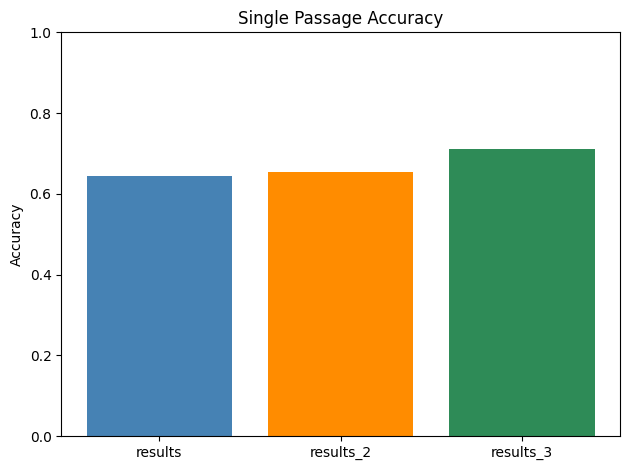

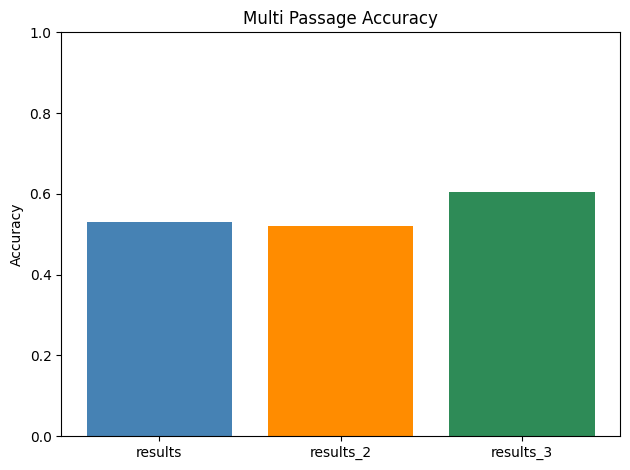

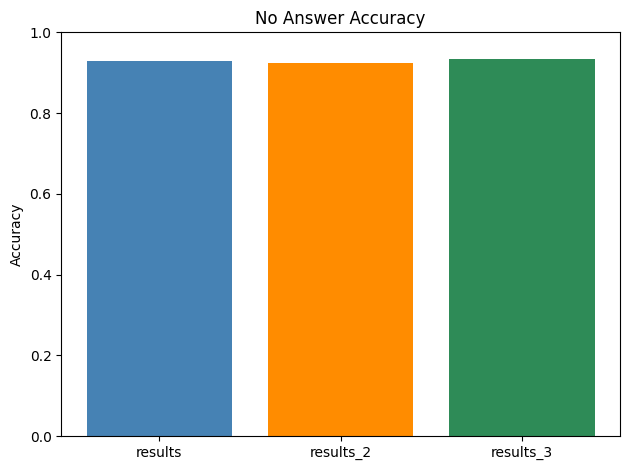

In [29]:
result_set = ["results", "results_2", "results_3"]


def summary(pd_result):
    total_questions = len(pd_result)
    score_sum = pd_result['score'].sum()
    accuracy = score_sum / (total_questions * 5)  # each question is scored out of 5
    mean = pd_result['score'].mean()
    median = pd_result['score'].median()
    return {'accuracy': accuracy, 'mean': mean, 'median': median}


def print_config(config_path):
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    print("Evaluation Parameters:")
    print(yaml.dump(config, default_flow_style=False, sort_keys=False))


# Store per type across result sets
single_passage_accuracies = []
multi_passage_accuracies = []
no_answer_accuracies = []

for result in result_set:
    results_directory = f"../../data/single_topic_rag_evaluation_dataset/{result}"
    print(f'\nEvaluating {result}...')

    pd_single_passage_result = pd.read_csv(f'{results_directory}/single_passage_answer_questions_predict.csv')
    single_passage_summary = summary(pd_single_passage_result)

    pd_multi_passage_result = pd.read_csv(f'{results_directory}/multi_passage_answer_questions_predict.csv')
    multi_passage_summary = summary(pd_multi_passage_result)

    pd_no_answer_result = pd.read_csv(f'{results_directory}/no_answer_questions_predict.csv')
    no_answer_summary = summary(pd_no_answer_result)

    single_passage_accuracies.append(single_passage_summary['accuracy'])
    multi_passage_accuracies.append(multi_passage_summary['accuracy'])
    no_answer_accuracies.append(no_answer_summary['accuracy'])

    print(f"Single Passage Accuracy: {single_passage_summary['accuracy']:.2f}")
    print(f"Multi Passage Accuracy: {multi_passage_summary['accuracy']:.2f}")
    print(f"No Answer Accuracy: {no_answer_summary['accuracy']:.2f}")
    #print_config(f'{results_directory}/config.yaml')

# --- Plotting ---
x = np.arange(len(result_set))  # bar positions
color_palette = ['steelblue', 'darkorange', 'seagreen', 'crimson', 'goldenrod', 'purple']


def plot_accuracies(data, title):
    plt.figure()
    plt.bar(x, data, color=color_palette, tick_label=result_set)
    plt.ylim(0, 1)
    plt.ylabel('Accuracy')
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_accuracies(single_passage_accuracies, 'Single Passage Accuracy')
plot_accuracies(multi_passage_accuracies, 'Multi Passage Accuracy')
plot_accuracies(no_answer_accuracies, 'No Answer Accuracy')